In [1]:
# # Viewing timeframe jumps

# def show_jumps(grouped):
#     frame_pattern = re.compile(r'_frame_(\d+)_')

#     inconsistent = {}
#     step_counts = defaultdict(int)

#     for key, files in grouped.items():
#         frame_nums = sorted(int(frame_pattern.search(f).group(1)) for f in files)
#         steps = set(frame_nums[i+1] - frame_nums[i] for i in range(len(frame_nums) - 1))
        
#         if len(steps) > 1:
#             inconsistent[key] = steps
#         elif steps:
#             step_counts[next(iter(steps))] += 1

#     print("Step size distribution across all videos:")
#     for step, count in sorted(step_counts.items()):
#         print(f"  step={step}: {count} video(s)")

#     if inconsistent:
#         print(f"\nVideos with inconsistent frame steps ({len(inconsistent)}):")
#         for key, steps in inconsistent.items():
#             print(f"  {key}: {steps}")
#     else:
#         print("\nAll videos have consistent frame steps.")

Dataset information
FF_data:
DFD -> Google's deepfake dection dataset
fake and real are faceforensics data

In CSV: 
0 - authentic videos
1 - deepfakes

In [2]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from PIL import Image
from torchvision import transforms
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import torch
import torch.nn as nn
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

Image.MAX_IMAGE_PIXELS = None
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [3]:
# Download and process data into frames

# Download all data
# !bash FaceForensics/download_ff_data.sh

# Download 10 videos data
# !bash download_ff_data.sh --num_videos 10 --frame_skip 20

# Download one video per category
# !bash download_ff_data.sh --sample --frame_skip 20

# for high quality, add --hq at the end
# !bash download_ff_data.sh --sample --hq

In [4]:
'''
group videos by name to get into format of map
'''

from collections import defaultdict
import re
import os
import pandas as pd

def group_by_video(directory):
    groups = defaultdict(list)
    for video_name in os.listdir(directory):
        video_path = os.path.join(directory, video_name)
        if not os.path.isdir(video_path):
            continue
        frames = sorted(f for f in os.listdir(video_path) if f.endswith('.png'))
        if frames:
            groups[video_name] = [os.path.join(video_name, f) for f in frames]
    
    result = []
    for key, frames in groups.items():
        result.append([key, frames])
    return result


#print(group_by_video("FF_data/real/original_sequences/youtube/c40/images"))

In [5]:
'''
create csv storing:
Video_name, frame 1, frame 2, .. frame 10
'''

all_dirs = ['FF_data/real/original_sequences/youtube/c40/images', 
            'FF_data/fake/manipulated_sequences/Deepfakes/c40/images',
            'FF_data/DFD_real/original_sequences/actors/c40/images',
            'FF_data/DFD_fake/manipulated_sequences/DeepFakeDetection/c40/images',
            'FF_data/Face2Face/manipulated_sequences/Face2Face/c40/images',
            'FF_data/FaceSwap/manipulated_sequences/FaceSwap/c40/images',
            'FF_data/NeuralTextures/manipulated_sequences/NeuralTextures/c40/images'
            ]

'''
0 - Authentic
1 - Deepfake
'''

def create_datamap(all_dirs):
    data = {
        'root_dir': [],
        'video_name': []
    }
    for i in range(10):
        data['frame_' + str(i)] = []
    
    data['label'] = []

    for dir in all_dirs:
        label = 1
        if 'original' in dir:
            label = 0
        video_map = group_by_video(dir)
        for video, frames in video_map:
            i = 0
            for j in range(10, len(frames), 10):
                split = frames[i:j]
                i = j
                data['root_dir'].append(dir)
                data['video_name'].append(video)
                data['label'].append(label)
                for k in range(len(split)):
                    data['frame_' + str(k)].append(split[k])
    return data

data_map = create_datamap(all_dirs)

df = pd.DataFrame(data_map)
df.to_csv('dataset_splits.csv', index=False) # for testing dataset


In [6]:
from torchvision import transforms
from sklearn.model_selection import train_test_split

class FrameDataset(Dataset):
    def __init__(self, df, res=500, transform=None):
        self.df = df
        self.transform = transform or transforms.ToTensor()
        self.res = res

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        """
        Returns a clip tensor of shape (3, T, H, W) = (3, 10, 500, 500).
        The DataLoader will stack these into (B, 3, T, H, W).
        """
        root_dir = self.df.iloc[idx, 0]
        tensors = []
        for i in range(10):
            fname = self.df.iloc[idx, i + 2]  # cols 2–11 are frame_0–frame_9
            path = os.path.join(root_dir, fname)
            img = Image.open(path).convert('RGB').resize((self.res, self.res))
            tensors.append(self.transform(img)) # (3, res, res)
        clip = torch.stack(tensors, dim=1) # (3, T, res, res)
        label = self.df.iloc[idx, -1]
        return clip, label


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

train_dataset = FrameDataset(train_df.reset_index(drop=True), res=224, transform=train_transform)
test_dataset  = FrameDataset(test_df.reset_index(drop=True), res=224, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset,  batch_size=32)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")
for frames, label in train_loader:
    print(frames.shape)
    print(label)
    break


Train samples: 10, Test samples: 3
torch.Size([10, 3, 10, 224, 224])
tensor([0, 1, 1, 0, 1, 1, 0, 0, 1, 1])


In [7]:
# Model

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

print(f'Model:      ResNet-50 (from scratch)')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Device:     {device}')

Model:      ResNet-50 (from scratch)
Parameters: 23,512,130
Device:     cpu


In [ ]:
# Training

criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
NUM_EPOCHS = 1

train_losses = []
train_accs   = []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for clips, labels in train_loader:
        # clips: (B, 3, T, H, W) — flatten T into batch dimension
        clips, labels = clips.to(device), labels.to(device)
        B, C, T, H, W = clips.shape

        optimizer.zero_grad()

        frames = clips.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)  # (B*T, 3, H, W)
        frame_outputs = model(frames)                                     # (B*T, 2)
        outputs = frame_outputs.reshape(B, T, -1).mean(dim=1)            # (B, 2) averaged logits per clip

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds    = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')
    if epoch % 10 == 0:
      print("saved checkpoint", epoch)
      torch.save({
          'epoch': epoch,
          'model_state_dict': model.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
          'loss': loss,
      }, f'/content/checkpoints/checkpoint_epoch_{epoch}.pt')

print('\nTraining Done')

Epoch 01/1 | Loss: 1.4277 | Acc: 0.7000
saved checkpoint 0

Training Done


In [ ]:
# saving training results
save_path = '/content/resnet50_baseline_scratch.pth'
torch.save(model.state_dict(), save_path)
print(f'Model saved to {save_path}')

Model saved to resnet50_baseline_scratch.pth


In [12]:
# Evaluation

model = models.resnet50(pretrained=False) # Change to resnet50
model.fc = nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load(save_path, map_location=device))
model = model.to(device)
model.eval()
print('Model loaded.')

/Users/cvancaemelbecke/opt/anaconda3/envs/ML_TA/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/cvancaemelbecke/opt/anaconda3/envs/ML_TA/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded.


In [14]:
# Evaluation Metrics
y_true, y_pred = [], []

with torch.no_grad():
    for clips, labels in test_loader:
        clips = clips.to(device)
        B, C, T, H, W = clips.shape

        frames = clips.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)  # (B*T, 3, H, W)
        frame_outputs = model(frames)                                     # (B*T, 2)
        outputs = frame_outputs.reshape(B, T, -1).mean(dim=1)            # (B, 2) averaged per clip

        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

print('=== BASELINE RESULTS (Clip-Level Averaged Logits) ===\n')
print(classification_report(
    y_true, y_pred,
    labels=[0, 1],
    target_names=['Real (0)', 'Fake (1)'],
    zero_division=0
))
print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred, labels=[0, 1]))
print(f'\nF1 (weighted): {f1_score(y_true, y_pred, average="weighted", zero_division=0):.4f}')
print(f'F1 (macro):    {f1_score(y_true, y_pred, average="macro", zero_division=0):.4f}')

=== BASELINE RESULTS (Clip-Level Averaged Logits) ===

              precision    recall  f1-score   support

    Real (0)       0.00      0.00      0.00         1
    Fake (1)       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3

Confusion Matrix:
[[0 1]
 [0 2]]

F1 (weighted): 0.5333
F1 (macro):    0.4000


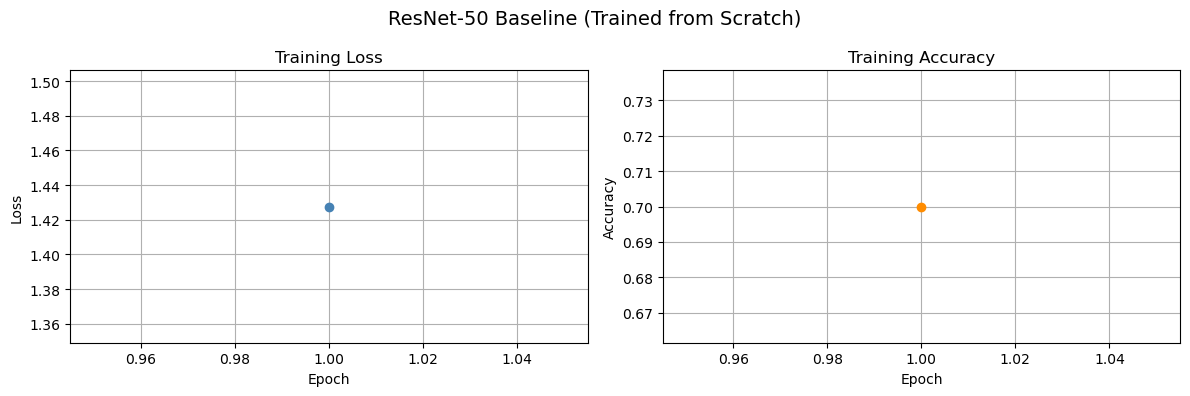

Saved


In [ ]:
# Evalution plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, NUM_EPOCHS+1), train_losses, marker='o', color='steelblue')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(range(1, NUM_EPOCHS+1), train_accs, marker='o', color='darkorange')
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True)

plt.suptitle('ResNet-50 Baseline (Trained from Scratch)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/baseline_training_curves.png')
plt.show()
print('Saved')